<a href="https://colab.research.google.com/github/yasmina2006/AI_GROUP_PROJECT/blob/main/AIML_House_price_prediction_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOUSE PRICE PREDICTION MODEL

## The project pipeline:
##### Objective: Our main goal is to implement a Linear Regression Model from scratch using Numpy and Scikit-learn libraries for house price prediction


1.   Data Collection: Importing the Tashkent Housing Dataset from Kaggle
2.   Data Preprocessing: Handling missing values, splitting the data, and applying Feature Scaling
3.   Model Implementation: Building Batch Gradient Descent from scratch using NumPy
4.   Regularization: Applying L2 (Ridge) regularization to prevent overfitting.
5.   Evaluation: Analyzing model performance using R-squared ($R^2$) and visualization.


## First of all , we will upload our dataset from Kaggle

In [3]:
from google.colab import files
files.upload()

Saving archive.zip to archive (1).zip


{'archive (1).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00\xec\x91\x91T\xc7\xff\xe0\x11\xff\xff\xff\xff\xff\xff\xff\xff\x16\x00\x14\x00dataset_cleaned_55.csv\x01\x00\x10\x00\xd7\x1f\x00\x00\x00\x00\x00\x00\xb9\x08\x00\x00\x00\x00\x00\x00uY\xcd\x8e.\xa9\r\xdd\xb7\xd4oR\xaa\xf0g\x03\xcbl\xb2\x1e\x8df?\x1aE\xb3\x884QK7\xf3\xfe\x8a\r\xf8\x07\x9a[\xad{\x17E\x01\xc6>>>\xe6\xfb\xe5\xc7\x7f\xfe\xfd\xe7\xf3\xcf\x1f\x7f\xfe\xf1\xfc\xeb\xaf\xaf\xaf\x1f\xcf\xaf__\xff\xfd\xdf\xf3\xdb\xd7\xdf\x7f\xfc\xf5\xfb|3\xfe\xff\x87\xbe\xf9\xf1\xf9\xd1j\x98\xcf\xd3\xd2S\x9f\xfc\xf4\'\xbcu=\xed\xf3#E\x19O\xf9IO\xa4/\xc2\x8b\xeb\xa94?\xe3\x1a\xaf\x8d\xc6\xf2Sx>|~@\x865P\x80&\xa6\x07h\xa0|~T(\xeb=\xe2\xc3K\xca\x84\x12\x93L\xc8o\xe5\xef#\xff#\x13\xb0\xe65\x12!\x8c-\xd8\xc8,\x0fM\r2\x95\x0e\x11\xf9\x93\x98\xe8\x8b\xe6\xbePk*\xef\xc8k\xd0\xcaEm\xa9@k\xf2\xe1\xe9-\xe8v\x1d\xc8%\xe5t\t$\x19\x87J6\xce\x93%z\xbf\x16\x1b\xae\x80\xe5JX\x0f~~\xc4j\xbe\xa2ydg\xe4\xedbH\xf2:\x8e\x7fl\xdba~\xafz\xc0NK\x97oK\xc7\xd6\xe4\x03\xf6\xf6

In [4]:
!unzip archive.zip

Archive:  archive.zip
replace dataset_cleaned_55.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: dataset_cleaned_55.csv  


In [5]:
import pandas as pd
df = pd.read_csv('dataset_cleaned_55.csv')
df.head()

,Price,Area,Floor,Rooms,Total_Floor,Floor/Total_Flor
0,870000000,82.0,7,3,9,0.777778
1,210000000,23.0,2,1,3,0.666667
2,836000000,78.0,3,3,4,0.750000
3,535000000,45.0,2,2,5,0.400000
4,754000000,66.0,3,2,4,0.750000


In [6]:
# here we load the data
df = pd.read_csv('dataset_cleaned_55.csv')

# we will look through column names and data types
print("--- Column Info ---")
print(df.info())

df.head()

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             300 non-null    int64  
 1   Area              300 non-null    float64
 2   Floor             300 non-null    int64  
 3   Rooms             300 non-null    int64  
 4   Total_Floor       300 non-null    int64  
 5   Floor/Total_Flor  300 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 14.2 KB
None


,Price,Area,Floor,Rooms,Total_Floor,Floor/Total_Flor
0,870000000,82.0,7,3,9,0.777778
1,210000000,23.0,2,1,3,0.666667
2,836000000,78.0,3,3,4,0.750000
3,535000000,45.0,2,2,5,0.400000
4,754000000,66.0,3,2,4,0.750000


### Feature Scaling

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# here we select our features
X = df[['Area', 'Floor', 'Rooms', 'Total_Floor']]
y = df['Price']
# splitting the data (80% for training , 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# actual scaling to have mean=0 and variance=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# adding a bias column to X_train and X_test
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print("Preprocessing complete! Shape of training data: ", X_train_final.shape)

Preprocessing complete! Shape of training data:  (240, 5)


### Calculation of weights

In [8]:
theta = np.zeros(X_train_final.shape[1])
# setting up hyperparameters
learning_rate = 0.01
epochs = 1000
m = len(y_train)
# for keeping thr track of the error over time
cost_history = []
# actual training loop
for i in range(epochs):
  predictions = X_train_final.dot(theta)
  # calculation of the error
  errors = predictions - y_train
  gradient = (1/m)* X_train_final.T.dot(errors)
  # now we update the weights
  theta = theta - (learning_rate * gradient)
  cost = (1/(2*m) * np.sum(np.square(errors)))
  cost_history.append(cost)
print("Training finished! Final weights calculated.")

Training finished! Final weights calculated.


### Visualization of cost function

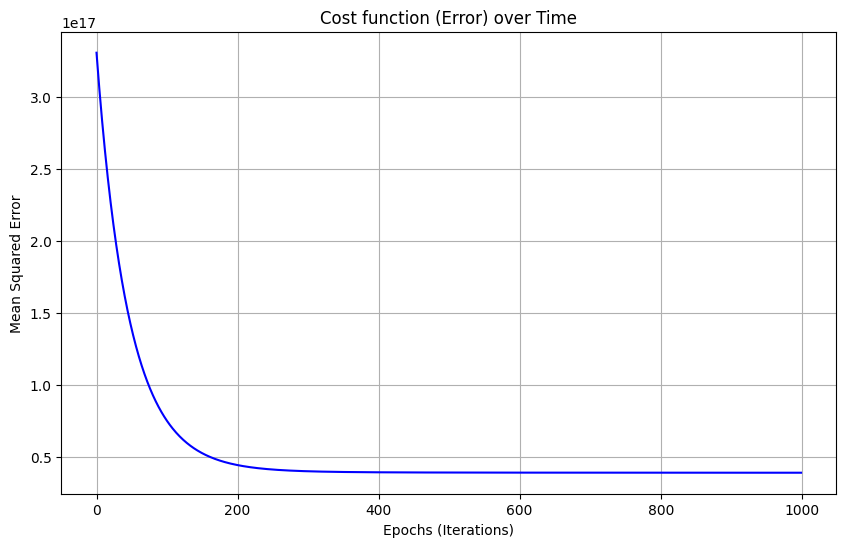

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(range(epochs),cost_history, color='blue')
plt.title("Cost function (Error) over Time")
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

In [10]:
# prediction of prices using the test set
y_pred = X_test_final.dot(theta)
comparison = pd.DataFrame(
    {
        'Actual': y_test,
        'Predicted': y_pred
    }
)
print(comparison.head())

        Actual     Predicted
203  508000000  5.570911e+08
266  947000000  9.523743e+08
152  780000000  7.562981e+08
9    454000000  7.181943e+08
233  492000000  6.210798e+08


In [11]:
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f"R-squared Score: {r2:.4f}")

R-squared Score: 0.6791


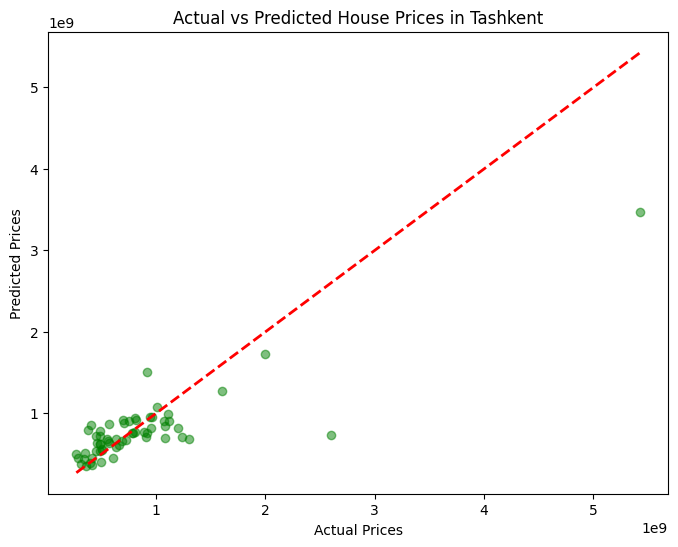

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices in Tashkent')
plt.show()

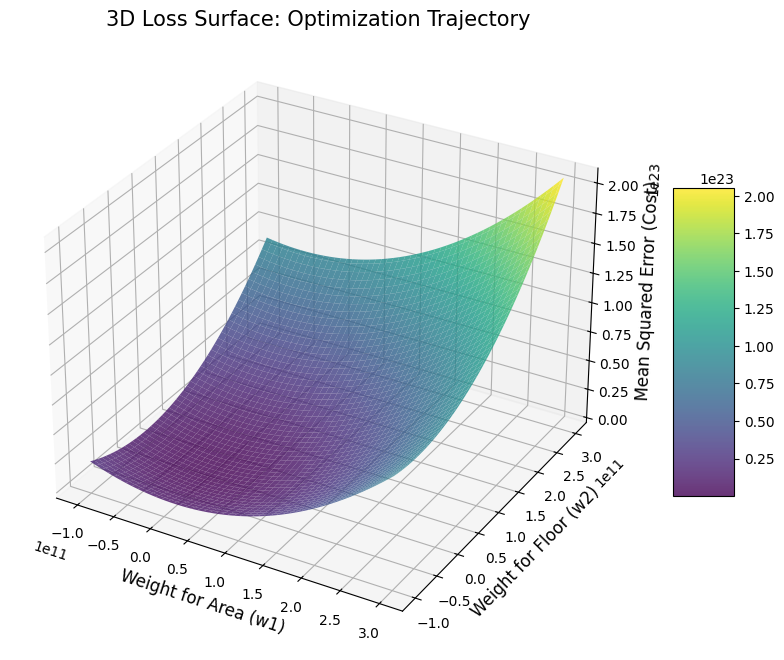

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# we take our scaled features and target
# (Assuming X_train_final and y_train are already defined from your code)
X_subset = X_train_final[:, [1, 2]] # Taking weights for 'Area' and 'Floor'
y_subset = y_train

# creating a grid of possible Weight values (theta_1 and theta_2)
w1_range = np.linspace(-1e11, 3e11, 100)
w2_range = np.linspace(-1e11, 3e11, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
Cost = np.zeros(W1.shape)

# calculating the Cost (MSE) for every combination of weights
for i in range(100):
    for j in range(100):
        # Prediction: y_hat = w1*x1 + w2*x2
        # Simplified for visualization purposes
        predictions = W1[i,j] * X_subset[:, 0] + W2[i,j] * X_subset[:, 1]
        Cost[i,j] = np.mean((predictions - y_subset)**2)

# plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# The Surface
surf = ax.plot_surface(W1, W2, Cost, cmap='viridis', alpha=0.8, edgecolor='none')

# Labels
ax.set_title('3D Loss Surface: Optimization Trajectory', fontsize=15)
ax.set_xlabel('Weight for Area (w1)', fontsize=12)
ax.set_ylabel('Weight for Floor (w2)', fontsize=12)
ax.set_zlabel('Mean Squared Error (Cost)', fontsize=12)

# Add a color bar
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

In [14]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
# training the model
model_sklearn = Ridge(alpha=0.1)
model_sklearn.fit(X_train_scaled, y_train)
# making predictions
y_pred_sklearn = model_sklearn.predict(X_test_scaled)
# calculating the metrics
r2_sklearn = r2_score(y_test, y_pred_sklearn)
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))
print("--- Scikit-learn Results ---")
print(f"R-squared Score: {r2_sklearn:.4f}")
print(f"Root Mean Squared Error: {rmse_sklearn:.2f}")

print("\n--- Numpy Results ---")
print(f"R-squared Score: {r2:.4f}")

--- Scikit-learn Results ---
R-squared Score: 0.6863
Root Mean Squared Error: 405795794.09

--- Numpy Results ---
R-squared Score: 0.6791


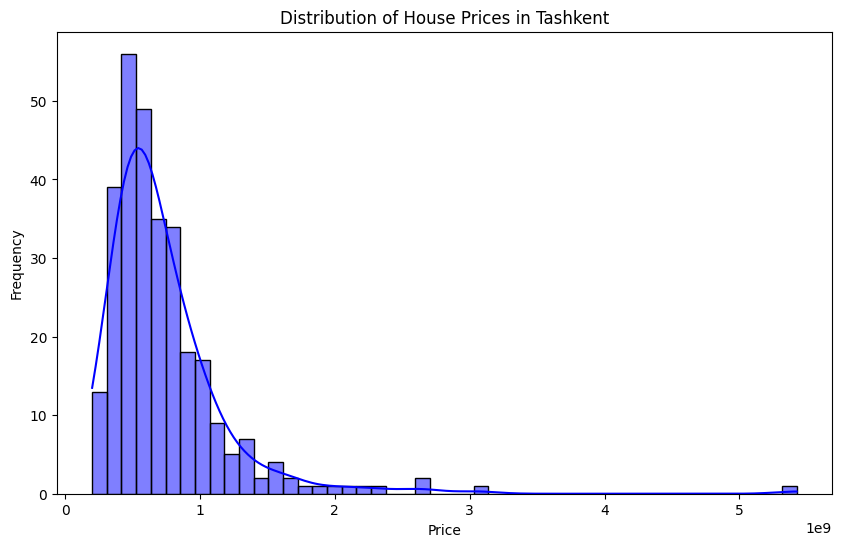

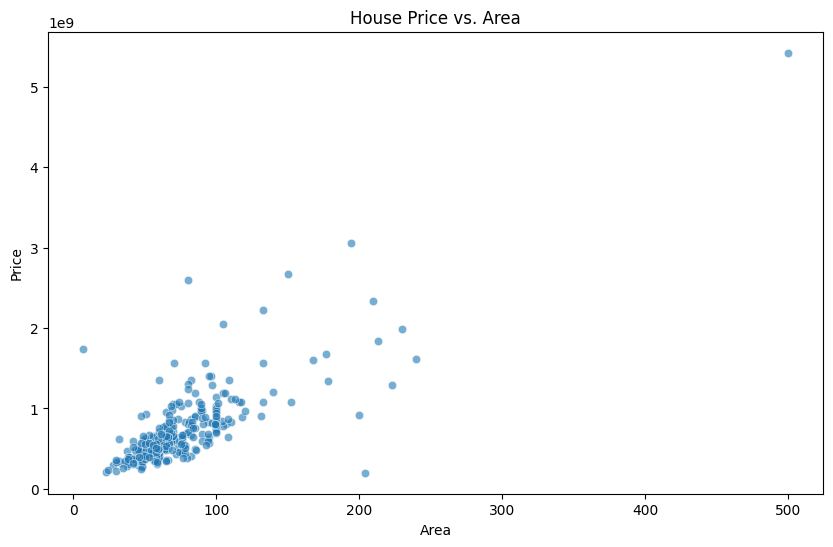

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# distribution of the Target Variable (Price)
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of House Prices in Tashkent')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# relationship between Area and Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Area', y='Price', alpha=0.6)
plt.title('House Price vs. Area')
plt.show()

## Model Improvement Analysis

In [16]:
# feature engineering
# adding new logic to help the model understand the data better
df['Floor_Ratio'] = df['Floor'] / df['Total_Floor']
df['Area_Squared'] = df['Area'] ** 2

# selecting the improved feature set
features = ['Area', 'Floor', 'Rooms', 'Total_Floor', 'Floor_Ratio', 'Area_Squared']
X = df[features].values
y = df['Price'].values

# preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# adding bias column (The "ones" trick)
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# training with Optimized Parameters
learning_rate = 0.01  # we found this is the best 'alpha'
epochs = 1000
lambda_reg = 0.1      # L2 Regularization strength
m, n = X_train_final.shape
theta = np.zeros(n)

for i in range(epochs):
    predictions = X_train_final.dot(theta)
    errors = predictions - y_train

    # gradient with L2 Penalty
    reg_term = (lambda_reg / m) * theta
    reg_term[0] = 0 # do not regularize the bias term
    gradient = (1/m) * X_train_final.T.dot(errors) + reg_term

    theta = theta - (learning_rate * gradient)

# results
y_pred = X_test_final.dot(theta)
new_r2 = r2_score(y_test, y_pred)
print(f"Improved R-squared Score: {new_r2:.4f}")

Improved R-squared Score: 0.7641


## Visualization of how our model got improved

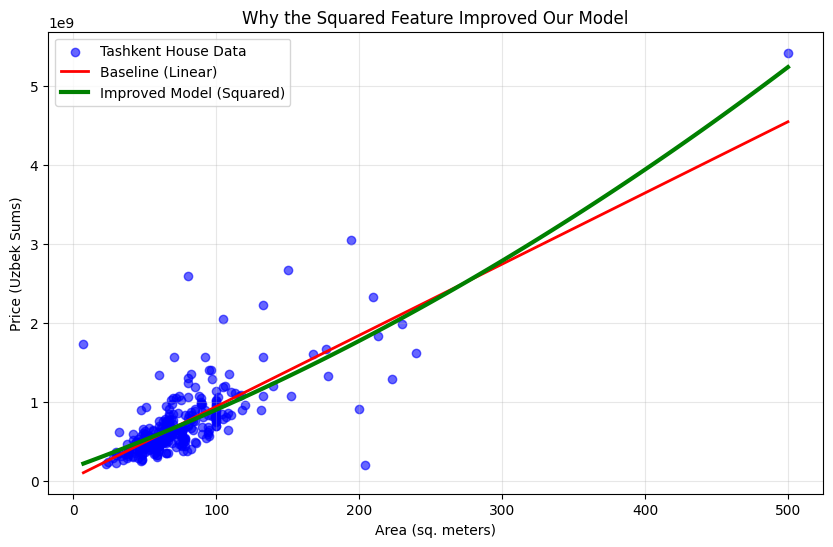

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# preparing the data
X_area = df[['Area']].values
y_price = df['Price'].values

# simple linear model (The "Straight Line" approach)
model_linear = LinearRegression()
model_linear.fit(X_area, y_price)

# polynomial model (The "Squared Feature" approach)
# we create a version of X that includes Area and Area squared
X_poly = np.hstack([X_area, X_area**2])
model_poly = LinearRegression()
model_poly.fit(X_poly, y_price)

# creating points for a smooth line plot
X_range = np.linspace(X_area.min(), X_area.max(), 100).reshape(-1, 1)
y_linear_line = model_linear.predict(X_range)

X_range_poly = np.hstack([X_range, X_range**2])
y_poly_line = model_poly.predict(X_range_poly)

# plotting the comparison
plt.figure(figsize=(10, 6))
plt.scatter(X_area, y_price, color='blue', alpha=0.6, label='Tashkent House Data')
plt.plot(X_range, y_linear_line, color='red', linewidth=2, label='Baseline (Linear)')
plt.plot(X_range, y_poly_line, color='green', linewidth=3, label='Improved Model (Squared)')

plt.title('Why the Squared Feature Improved Our Model')
plt.xlabel('Area (sq. meters)')
plt.ylabel('Price (Uzbek Sums)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()